In [2]:
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Meghna
[nltk_data]     Tomar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Meghna
[nltk_data]     Tomar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
resume_df = pd.read_csv("../datasets/resumes.csv")
job_df = pd.read_csv("../datasets/jobs.csv")

In [5]:
job_df.drop(columns=["Unnamed: 0"], inplace=True)

print(job_df.columns)

Index(['Job Title', 'Job Description'], dtype='str')


In [6]:
print("Resume duplicates:", resume_df.duplicated().sum())

print("Job duplicates:", job_df.duplicated().sum())

Resume duplicates: 0
Job duplicates: 0


In [7]:
resume_df.drop_duplicates(inplace=True)

job_df.drop_duplicates(inplace=True)

In [8]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
resume_df["cleaned_resume"] = resume_df["Resume_str"].apply(clean_text)

job_df["cleaned_job_description"] = job_df["Job Description"].apply(clean_text)

In [10]:
print("ORIGINAL RESUME:\n")
print(resume_df["Resume_str"][0])

print("\n==============================\n")

print("CLEANED RESUME:\n")
print(resume_df["cleaned_resume"][0])

ORIGINAL RESUME:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [11]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):

    # lowercase
    text = text.lower()

    # remove html
    text = BeautifulSoup(text, "html.parser").get_text()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # replace special chars with spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma_word)

    return " ".join(cleaned_words)

In [12]:
resume_df["nlp_processed_resume"] = resume_df["Resume_str"].apply(advanced_clean_text)

job_df["nlp_processed_job_description"] = job_df["Job Description"].apply(advanced_clean_text)

In [13]:
print("ADVANCED CLEANED RESUME:\n")

print(resume_df["nlp_processed_resume"][0])

ADVANCED CLEANED RESUME:

hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team management marketing savvy conflict resolution technique training development skilled multi tasker client relation specialist accomplishment missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality system hilton onq micros opera pm fidelio opera reservation system or holidex completed course seminar customer service sale strategy inventory control loss prevention safety time management leadership performance assessment experience hr administrator marketing associate hr administrator dec current company name city state 

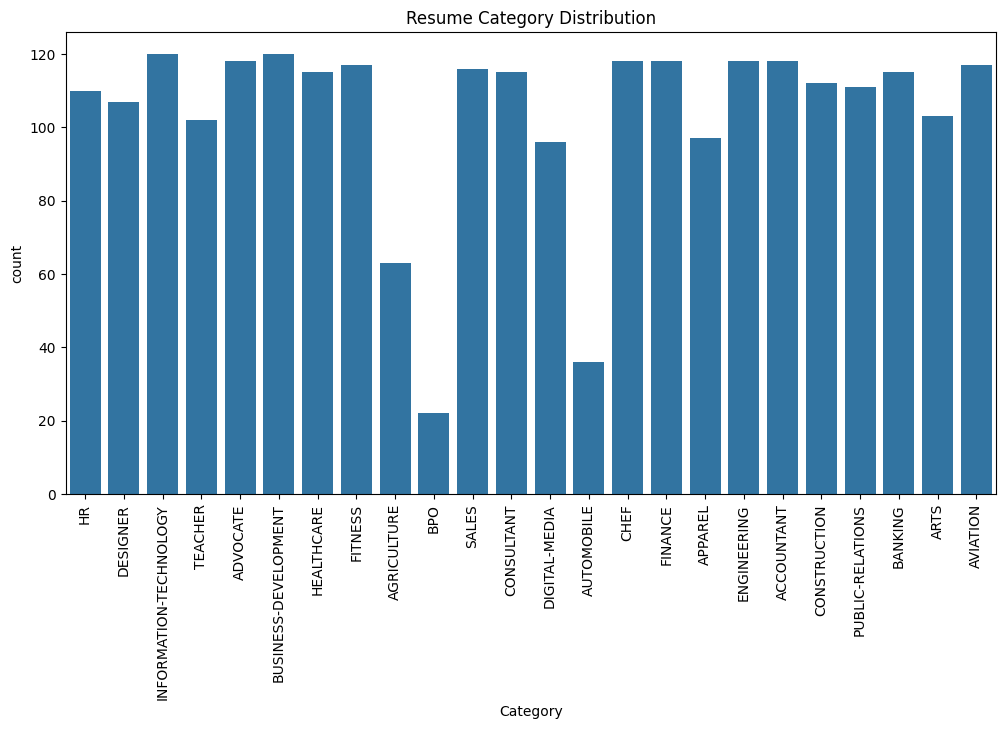

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(x=resume_df["Category"])

plt.xticks(rotation=90)

plt.title("Resume Category Distribution")

plt.show()

In [15]:
resume_df["resume_length"] = resume_df["nlp_processed_resume"].apply(len)

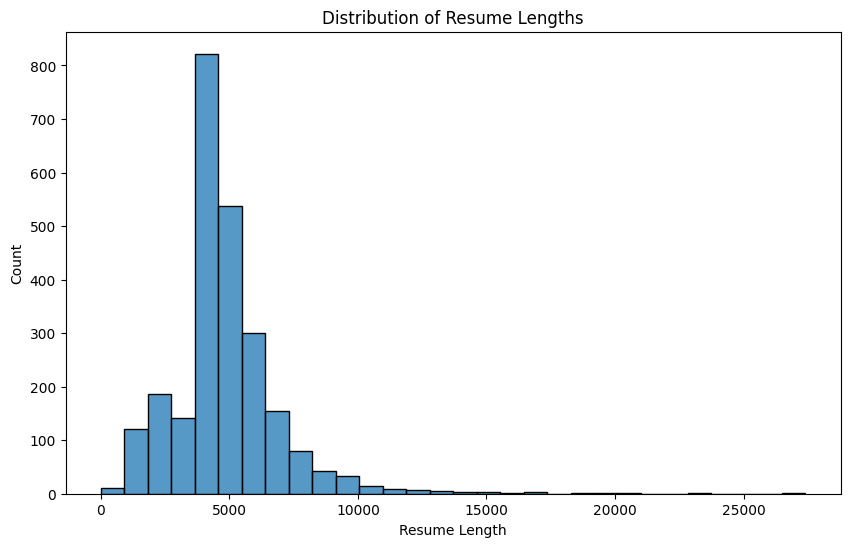

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(resume_df["resume_length"], bins=30)

plt.title("Distribution of Resume Lengths")

plt.xlabel("Resume Length")

plt.show()

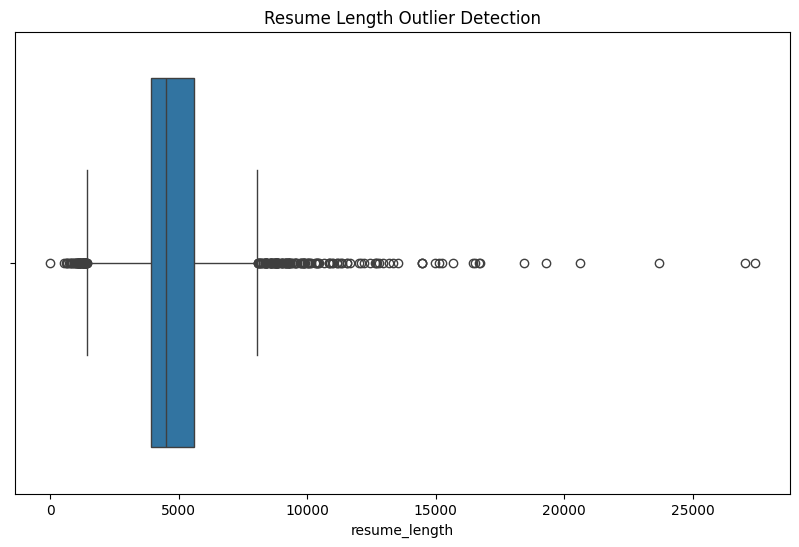

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(x=resume_df["resume_length"])

plt.title("Resume Length Outlier Detection")

plt.show()

In [18]:
short_resumes = resume_df[resume_df["resume_length"] < 1000]

print(short_resumes[["Category", "resume_length"]].head())

long_resumes = resume_df[resume_df["resume_length"] > 8000]

print(long_resumes[["Category", "resume_length"]].head())

                  Category  resume_length
130               DESIGNER            600
153               DESIGNER            764
656   BUSINESS-DEVELOPMENT              0
1026                 SALES            951
1039                 SALES            745
   Category  resume_length
22       HR           8720
33       HR          10154
81       HR          12961
87       HR          10837
89       HR          10313


In [19]:
skill_variations = {

    "python": ["python", "py"],

    "java": ["java"],

    "javascript": ["javascript", "js", "java script"],

    "machine learning": [
        "machine learning",
        "ml"
    ],

    "deep learning": [
        "deep learning",
        "dl"
    ],

    "natural language processing": [
        "natural language processing",
        "nlp"
    ],

    "sql": ["sql", "mysql", "postgresql"],

    "react": ["react", "reactjs", "react.js"],

    "flask": ["flask"],

    "django": ["django"],

    "tensorflow": ["tensorflow"],

    "pytorch": ["pytorch"],

    "html": ["html"],

    "css": ["css"],

    "git": ["git", "github"],

    "data analysis": [
        "data analysis",
        "data analytics"
    ],

    "communication": ["communication"],

    "leadership": ["leadership"]
}

In [20]:
def advanced_skill_extractor(text):

    extracted_skills = set()

    # tokenize words
    tokens = text.split()

    # create searchable text
    clean_text = " ".join(tokens)

    for standard_skill, variations in skill_variations.items():

        for variation in variations:

            variation = variation.lower()

            # multi-word skill
            if " " in variation:

                if variation in clean_text:
                    extracted_skills.add(standard_skill)

            # single-word skill
            else:

                if variation in tokens:
                    extracted_skills.add(standard_skill)

    return list(extracted_skills)

In [21]:
resume_df["advanced_skills"] = resume_df["nlp_processed_resume"].apply(
    advanced_skill_extractor
)

job_df["advanced_skills"] = job_df["nlp_processed_job_description"].apply(
    advanced_skill_extractor
)

In [22]:
print(
    resume_df[
        ["Category", "advanced_skills"]
    ].head(10)
)

  Category              advanced_skills
0       HR  [data analysis, leadership]
1       HR              [communication]
2       HR                 [leadership]
3       HR              [communication]
4       HR                 [leadership]
5       HR                           []
6       HR                 [leadership]
7       HR              [communication]
8       HR  [leadership, communication]
9       HR                           []


In [23]:
from collections import Counter

all_skills = []

for skills in resume_df["advanced_skills"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

print(skill_counts.most_common(15))

[('communication', 1479), ('leadership', 1026), ('sql', 191), ('html', 153), ('data analysis', 148), ('java', 67), ('javascript', 63), ('python', 40), ('git', 18), ('machine learning', 17), ('react', 5), ('tensorflow', 3), ('deep learning', 3), ('natural language processing', 2), ('flask', 1)]


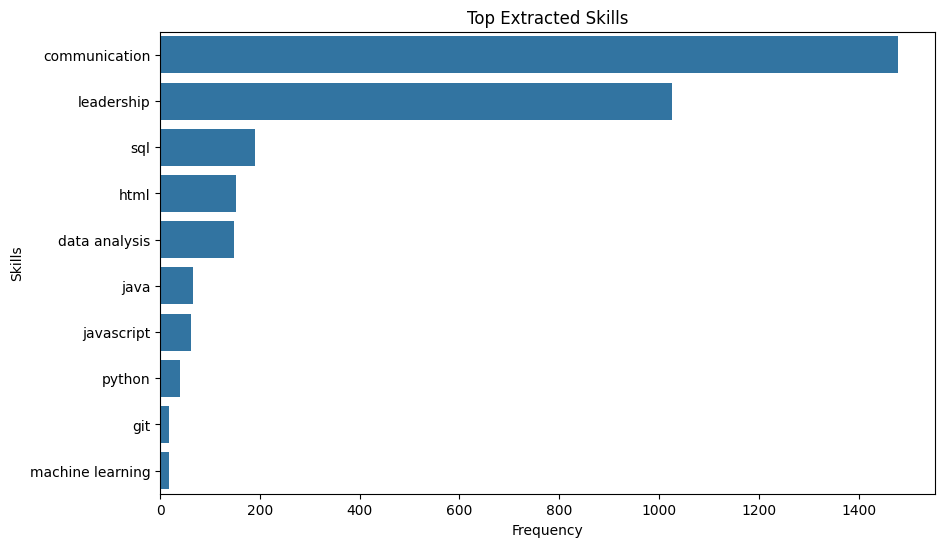

In [24]:
top_skills = skill_counts.most_common(10)

skills = [item[0] for item in top_skills]
counts = [item[1] for item in top_skills]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=skills)

plt.title("Top Extracted Skills")

plt.xlabel("Frequency")

plt.ylabel("Skills")

plt.show()

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
sample_resume = resume_df["nlp_processed_resume"][11]

sample_job = job_df["nlp_processed_job_description"][1]

In [27]:
vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform(
    [sample_resume, sample_job]
)

In [28]:
similarity_score = cosine_similarity(vectors[0], vectors[1])

print("Similarity Score:")

print(similarity_score)

Similarity Score:
[[0.08740115]]


In [29]:
match_percentage = round(similarity_score[0][0] * 100, 2)

print(f"Resume-Job Match Score: {match_percentage}%")

Resume-Job Match Score: 8.74%


In [30]:
resume_skills = resume_df["advanced_skills"][10]

job_skills = job_df["advanced_skills"][1]

print("Resume Skills:")
print(resume_skills)

print("\nJob Skills:")
print(job_skills)

Resume Skills:
['leadership', 'communication']

Job Skills:
['sql', 'python', 'communication', 'django', 'flask']


In [31]:
missing_skills = list(
    set(job_skills) - set(resume_skills)
)




In [32]:
if len(missing_skills) == 0:

    feedback = "Strong match. Resume covers most required skills."

else:

    feedback = (
        "Candidate may improve suitability by learning: "
        + ", ".join(missing_skills)
    )
    
if match_percentage >= 75:

    level = "Excellent Match"

elif match_percentage >= 50:

    level = "Moderate Match"

else:

    level = "Low Match"

print("Match Level:", level)
print(missing_skills)
print(feedback)

Match Level: Low Match
['django', 'sql', 'python', 'flask']
Candidate may improve suitability by learning: django, sql, python, flask


In [33]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [35]:
resume_embedding = model.encode(sample_resume)

job_embedding = model.encode(sample_job)

In [36]:
semantic_similarity = cosine_similarity(
    [resume_embedding],
    [job_embedding]
)

semantic_score = round(
    semantic_similarity[0][0] * 100,
    2
)

print("Semantic Match Score:")
print(f"{semantic_score}%")

Semantic Match Score:
37.63999938964844%


In [37]:
print("TF-IDF Match Score:", match_percentage)

print("Semantic Match Score:", semantic_score)

TF-IDF Match Score: 8.74
Semantic Match Score: 37.64


In [38]:
selected_job = job_df["nlp_processed_job_description"][0]

print(job_df["Job Title"][0])

print("\n====================\n")

print(selected_job[:1000])

Flutter Developer


looking hire expert flutter developer eligible post apply resume job type full time part time salary per month benefit flexible schedule food allowance schedule day shift supplemental pay joining bonus overtime pay experience total work year preferred housing rent subsidy yes industry software development work remotely temporarily due covid


In [39]:
all_resumes = resume_df["nlp_processed_resume"].tolist()

In [40]:
job_embedding = model.encode(selected_job)

resume_embeddings = model.encode(all_resumes)

In [41]:
similarity_scores = cosine_similarity(
    [job_embedding],
    resume_embeddings
)

In [42]:
scores = similarity_scores[0]

In [43]:
resume_df["semantic_match_score"] = scores

In [44]:
top_matches = resume_df.sort_values(
    by="semantic_match_score",
    ascending=False
)

In [45]:
top_matches[
    [
        "Category",
        "semantic_match_score",
        "advanced_skills"
    ]
].head(10)

,Category,semantic_match_score,advanced_skills
80,HR,0.509053,"[leadership, communication]"
1197,CONSULTANT,0.505866,[communication]
124,DESIGNER,0.505729,"[java, sql, git]"
91,HR,0.495438,"[java, sql, communication]"
589,BUSINESS-DEVELOPMENT,0.484154,[]
39,HR,0.482565,[communication]
258,INFORMATION-TECHNOLOGY,0.481550,"[leadership, sql, html, communication]"
1119,CONSULTANT,0.478474,[]
1124,CONSULTANT,0.478089,"[sql, communication, java, javascript, leaders..."
71,HR,0.475733,[communication]


In [46]:
top_matches["semantic_match_percentage"] = (
    top_matches["semantic_match_score"] * 100
).round(2)

In [47]:
top_matches[
    [
        "Category",
        "semantic_match_percentage",
        "advanced_skills"
    ]
].head(10)

,Category,semantic_match_percentage,advanced_skills
80,HR,50.910000,"[leadership, communication]"
1197,CONSULTANT,50.590000,[communication]
124,DESIGNER,50.570000,"[java, sql, git]"
91,HR,49.540001,"[java, sql, communication]"
589,BUSINESS-DEVELOPMENT,48.419998,[]
39,HR,48.259998,[communication]
258,INFORMATION-TECHNOLOGY,48.160000,"[leadership, sql, html, communication]"
1119,CONSULTANT,47.849998,[]
1124,CONSULTANT,47.810001,"[sql, communication, java, javascript, leaders..."
71,HR,47.570000,[communication]


In [48]:
def calculate_skill_overlap(resume_skills, job_skills):

    if len(job_skills) == 0:
        return 0

    matched_skills = set(resume_skills).intersection(set(job_skills))

    overlap_score = (
        len(matched_skills) / len(job_skills)
    ) * 100

    return round(overlap_score, 2)

In [57]:
resume_skills = resume_df["advanced_skills"][1]

job_skills = job_df["advanced_skills"][1]

skill_overlap_score = calculate_skill_overlap(
    resume_skills,
    job_skills
)

print("Skill Overlap Score:")
print(skill_overlap_score)

Skill Overlap Score:
20.0


In [58]:
def calculate_resume_quality(resume_text):

    score = 0

    word_count = len(resume_text.split())

    # ideal resume length
    if 300 <= word_count <= 1200:
        score += 40

    # technical keywords
    technical_keywords = [
        "project",
        "experience",
        "skill",
        "education",
        "university",
        "developer"
    ]

    for keyword in technical_keywords:

        if keyword in resume_text:
            score += 10

    return min(score, 100)

In [59]:
quality_score = calculate_resume_quality(
    sample_resume
)

print("Resume Quality Score:")
print(quality_score)

Resume Quality Score:
90
